# Locality Sensitive Hashing (LSH) for Document Retrieval

This notebook implements a complete Locality Sensitive Hashing (LSH) pipeline for efficient document similarity search using the **20 Newsgroups** dataset.

### Project Overview:
1. **Data Preprocessing & Vectorization:** Load text data, clean it, and compute TF-IDF vectors.
2. **LSH Signature Generation:** Use random projection (hyperplanes) to generate 1024-bit binary hashes for each document.
3. **Banding Technique:** Split the signatures into multiple bands and rows to build an inverted index for fast candidate retrieval.
4. **Query Pipeline & Evaluation:** Retrieve candidate documents, compute actual cosine similarities, and evaluate the True Positive Rate (TPR) across varying thresholds and band configurations.

**Responsibilities:**
- Load and clean the 20 Newsgroups dataset.
- Implement TfidfVectorizer to transform documents into vectors.
- Generate 1024-bit LSH hash using random hyperplanes.
- Ensure each hash function outputs a 1-bit value based on the sign of the dot product.

**Key Deliverables:**
- TF-IDF matrix for all articles.
- Hash matrix (each row = article, each column = hash bit).
- Function to generate hyperplanes and compute hashes.

In [ ]:
# Load and Preprocess the Dataset
from sklearn.datasets import fetch_20newsgroups

newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
articles = newsgroups_train.data

In [ ]:
# Remove all of "\n".
for i in range(len(articles)):
    articles[i] = articles[i].replace('\n', ' ')

In [ ]:
# Convert Articles into TF-IDF Vectors
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000)  # limit features for efficiency
tfidf_matrix = vectorizer.fit_transform(articles)  # Sparse matrix: (n_articles, vocab_size)

In [ ]:
# Generate Random Hyperplanes
import numpy as np

n_bits = 1024
vocab_size = tfidf_matrix.shape[1]

random_hyperplanes = np.random.randn(n_bits, vocab_size)

In [ ]:
# Compute 1024-bit Hash for Each Article
projections = tfidf_matrix @ random_hyperplanes.T  # Shape: (n_articles, n_bits)
binary_hashes = (projections > 0).astype(int)       # 1 if positive, 0 if negative

In [ ]:
result = {
    # for stage 3
    'tfidf_matrix': tfidf_matrix,
    # for stage 2
    'binary_hashes': binary_hashes
}
result

{'tfidf_matrix': <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 924035 stored elements and shape (11314, 10000)>,
 'binary_hashes': array([[1, 0, 0, ..., 0, 1, 0],
        [1, 0, 1, ..., 0, 1, 1],
        [1, 0, 0, ..., 0, 0, 1],
        ...,
        [0, 0, 0, ..., 1, 1, 1],
        [1, 0, 0, ..., 1, 1, 0],
        [1, 1, 1, ..., 1, 1, 1]])}

**Responsibilities**:

  - Split each hash into num_bands and num_rows.

  - Convert band bits into integers.

  - Organize band hash values into dictionaries (choose Option 1 or Option 2).

  - Provide lookup interface for query processing.

**Output**:

  - Band dictionaries to index article hashes.

  - Utility functions to encode band bits into integers

In [ ]:
# Set parameters
num_bands = 16
num_rows = n_bits // num_bands

In [ ]:
# Encode band bits into integers
def bits_to_int(bits):
    hash_value = 0
    for bit in bits:
        hash_value = (hash_value << 1) | bit
    return hash_value

In [ ]:
# Organize band hash values into dictionaries
def build_lsh_index(hashes, num_bands, num_rows):
    band_dicts = [{} for _ in range(num_bands)]  # Option 1: one dict per band

    for doc_id, bits in enumerate(hashes):
        for band_idx in range(num_bands): # Split each hash into bands
            start = band_idx * num_rows
            end = start + num_rows
            band_bits = bits[start:end]
            band_hash_value = bits_to_int(band_bits)

            # Insert into the appropriate band dictionary
            if band_hash_value not in band_dicts[band_idx]:
                band_dicts[band_idx][band_hash_value] = []
            band_dicts[band_idx][band_hash_value].append(doc_id)

    return band_dicts

In [ ]:
binary_hashes = result['binary_hashes']
band_dicts = build_lsh_index(binary_hashes, num_bands, num_rows)

for band_idx, band_table in enumerate(band_dicts):
    multiple_docs_buckets = [doc_ids for doc_ids in band_table.values() if len(doc_ids) > 1]
    print(f"Band {band_idx}: {len(multiple_docs_buckets)} buckets have > 1 documents")

Band 0: 55 buckets have > 1 documents
Band 1: 58 buckets have > 1 documents
Band 2: 58 buckets have > 1 documents
Band 3: 55 buckets have > 1 documents
Band 4: 58 buckets have > 1 documents
Band 5: 56 buckets have > 1 documents
Band 6: 57 buckets have > 1 documents
Band 7: 56 buckets have > 1 documents
Band 8: 57 buckets have > 1 documents
Band 9: 55 buckets have > 1 documents
Band 10: 56 buckets have > 1 documents
Band 11: 56 buckets have > 1 documents
Band 12: 55 buckets have > 1 documents
Band 13: 57 buckets have > 1 documents
Band 14: 56 buckets have > 1 documents
Band 15: 55 buckets have > 1 documents


**Responsibilities**:

- Implement the query pipeline: hash query doc → retrieve candidates → calculate cosine similarity → filter by threshold → return top N.

- Evaluate system performance (TPR/FNR) under different settings.

- Write the final report including code overview, experiment results, and visualization.

**Output:**

- Query recommendation function.

- TPR/FNR evaluation for multiple num_bands, num_rows, and threshold settings.

- Group report (with contributions, examples, and results).

In [ ]:
# Query
def query_article(article, num_band):
    # Preprocess
    article = article.replace('\n', ' ')

    # Hash to 1024 bits
    arti_tfidf = vectorizer.transform([article])
    proj = arti_tfidf @ random_hyperplanes.T
    arti_hash = (proj > 0).astype(int)

    # Calculate band values
    num_row = n_bits // num_band

    band_dicts = build_lsh_index(binary_hashes, num_band, num_row)
    arti_dict = build_lsh_index(arti_hash, num_band, num_row)

    # Find candidates
    candidates = set()

    for i in range(num_band):
        if list(arti_dict[i].keys())[0] in band_dicts[i]:
            candidates.update(band_dicts[i][list(arti_dict[i].keys())[0]])

    return candidates, arti_tfidf

In [ ]:
# Check Cosine similarity for all candidates
def check_similarity(article, num_band):
    candidates, arti_tfidf = query_article(article, num_band)
    candidates = list(candidates)

    candi_similar = {}

    for i in candidates:
        norm_arti = np.linalg.norm(arti_tfidf.toarray()[0])
        norm_candi = np.linalg.norm(tfidf_matrix[i].toarray())
        if norm_arti != 0 and norm_candi != 0:
            similar = np.dot(arti_tfidf.toarray()[0], tfidf_matrix[i].toarray().T) / (norm_arti * norm_candi)
            candi_similar[i] = similar
        else:
            candi_similar[i] = 0

    similar = list(candi_similar.items())

    # Add labels to articles
    labels = newsgroups_train.target
    for i in range(len(similar)):
        similar[i] = similar[i] + (labels[similar[i][0]],)

    return similar

In [ ]:
# Make recommendation and calculate true positive rate
import pandas as pd

def recommend(arti_num, similar, threshold, top_n):
    # similar = check_similarity(articles[arti_num], num_band)
    labels = newsgroups_train.target

    # Get top n recommendations
    filtered = [(i, j, k) for i, j, k in similar if j > threshold]
    top_n = sorted(filtered, key=lambda x: x[1], reverse=True)[0:top_n + 1]
    top_n = pd.DataFrame(top_n).rename(columns={0: 'Article ID', 1: 'Similarity', 2: 'Label'})
    top_n = top_n.rename(index={0: 'Target'})

    # Calculate true positive rate
    true_positive = 0
    for i in range(len(filtered)):
        if filtered[i][2] == labels[arti_num]:
            true_positive += 1

    denominator = np.sum(labels == labels[arti_num])
    true_positive_rate = true_positive / denominator

    return top_n, true_positive_rate

In [ ]:
# Show the recommendation list
similarity = check_similarity(articles[1444], 256)
top_n, tpr = recommend(1444, similarity, 0.1, 5)
print(top_n)
print(f"True Positive Rate: {tpr}")

        Article ID             Similarity  Label
Target        1444   [1.0000000000000002]      7
1            10045   [0.2553451506508775]     18
2             2554  [0.23918054861404664]      7
3             9202  [0.21978722338699094]      7
4             5315    [0.216814885451829]      7
5             5702  [0.21170256881868607]      7
True Positive Rate: 0.22895622895622897


In [ ]:
# Prepare for plot
thres = np.linspace(0, 0.0003, 8)
bands_num = np.array([94, 103, 114, 128, 147, 171, 205, 256])
Z = np.zeros((8, 8))

for i in range(len(bands_num)):
    temp = check_similarity(articles[144], int(bands_num[i]))
    for j in range(len(thres)):
        _, Z[i, j] = recommend(144, temp, thres[j], 10)

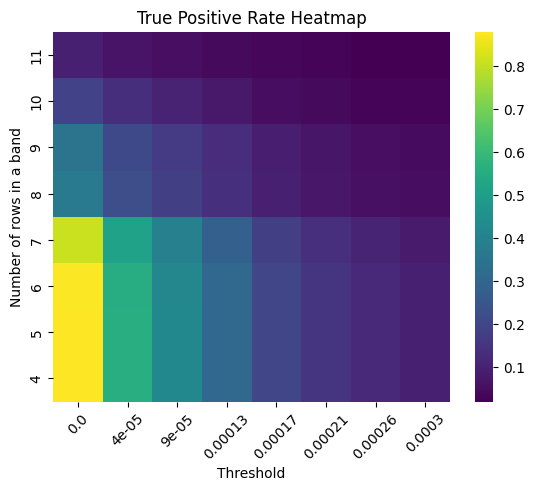

In [ ]:
# Draw the True Positive Rate Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

rounded = [round(num, 5) for num in thres]

sns.heatmap(Z, annot=False, cmap='viridis')
plt.xticks(np.arange(0.5, 8.5), rounded, rotation=45)
plt.yticks(np.arange(0.5, 8.5), np.arange(11, 3, -1))
plt.xlabel('Threshold')
plt.ylabel('Number of rows in a band')
plt.title('True Positive Rate Heatmap')
plt.savefig('my_plot.png')
plt.show()

## Evaluation Summary & Conclusion

The heatmap generated above visualizes the **True Positive Rate (TPR)** across different configurations of `thresholds` and `number of rows in a band`.

### Key Takeaways:
- **More rows per band** reduces the probability of a hash collision, leading to fewer candidates retrieved, which can lower the TPR but speeds up the process (reducing False Positives).
- **Lower thresholds** for cosine similarity typically yield higher TPR since we are more lenient with what is considered a "match", but this can introduce noise.
- The optimal setting depends on the specific requirements for recall vs. efficiency in a production environment.